# MPP aluminium model — conceptual structure

How the MPP aluminium model *decides*, for the GCAM × MPP linking deck — the decision engine, not the technology taxonomy.

**What it shows**
- The **yearly solve** (2020→2050): decommission → brownfield → greenfield, run in fixed order on an asset stack that is copied forward each year.
- Inside **brownfield**, the **retrofit-in-place vs rebuild-on-site** split, and the three ways the loop stops (under budget / ranking empty / 20% cap).
- The **abatement-cost ranking** (score = TCO ÷ ΔCO₂) built once and re-sliced each year.
- The **carbon budget** acting as an early-exit gate on brownfield, and **demand** as the exogenous driver.
- The **captive Scope 1 / grid Scope 2 split**: on-site fossil power sits in Scope 1 with process CO₂, grid/PPA electricity in Scope 2 — so a captive→grid switch moves emissions across the boundary, and grid intensity is the IAM/GCAM coupling point.

Source: `MODEL_REFERENCE.md` (yearly loop §3, agents §5–7, ranking §8, constraints/budget §10–12, emissions §15).

Output: `mpp_model_structure.svg` (transparent background) and `.png`.

saved mpp_model_structure.svg / .png


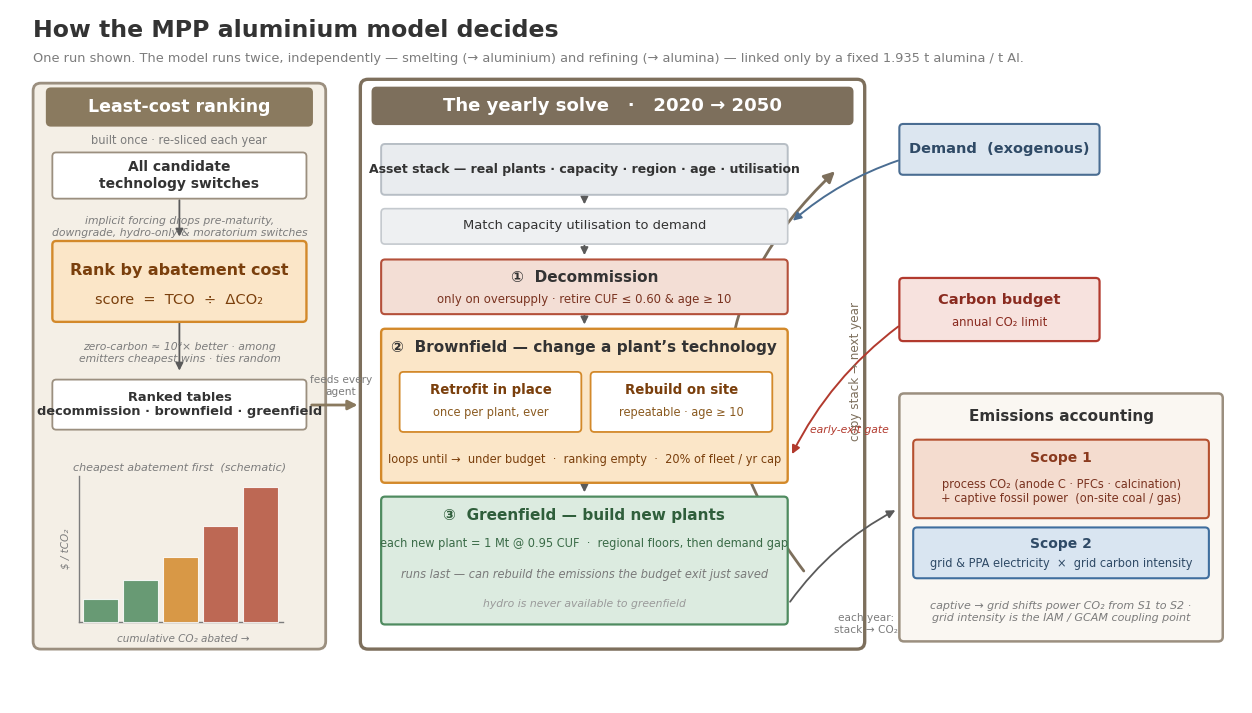

In [2]:
# MPP aluminium model — conceptual structure (the yearly decision engine)
# Renders an SVG with a transparent background for the GCAM x MPP deck.
# Shows: the decommission -> brownfield -> greenfield loop, retrofit vs rebuild,
# the abatement-cost ranking, the carbon-budget early-exit, and the captive
# Scope 1 / grid Scope 2 emissions split. Verified against MODEL_REFERENCE.md.

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle

# ---- palette ---------------------------------------------------------------
TXT   = "#333333"; MUT = "#7c7c7c"; ARROW = "#5a5a5a"
NB    = "#9b8f7f"                                  # neutral container border
TAN_H = "#8a7a5f"; TAN_F = "#f4efe6"; WHT = "#ffffff"
SLATE_F = "#e9ecef"; SLATE_E = "#b7bec5"
GREY_F  = "#eef0f2"; GREY_E = "#c4c9ce"
BRICK_E = "#b4503a"; BRICK_F = "#f3ded5"
AMB_E   = "#d3892a"; AMB_F  = "#fbe6c8"
GRN_E   = "#4f8b60"; GRN_F  = "#dcebe0"
STEEL_E = "#4a6d92"; STEEL_F = "#dce6f0"
BUD_E   = "#b23a2e"; BUD_F  = "#f7e2de"
S1_E    = "#b5502f"; S1_F   = "#f4dccf"
S2_E    = "#3f6e9e"; S2_F   = "#d9e5f1"
LOOP_E  = "#7d6f5c"

# ---- helpers ---------------------------------------------------------------
def rbox(x0, y0, x1, y1, fc, ec, lw=1.6, r=0.05, z=3):
    ax.add_patch(FancyBboxPatch((x0, y0), x1-x0, y1-y0,
        boxstyle=f"round,pad=0,rounding_size={r}", linewidth=lw,
        edgecolor=ec, facecolor=fc, mutation_aspect=1.0, zorder=z))
    return (x0+x1)/2, (y0+y1)/2

def T(x, y, s, fs=10, fw="bold", c=TXT, ha="center", va="center",
      style="normal", z=4, rotation=0):
    ax.text(x, y, s, fontsize=fs, fontweight=fw, color=c, ha=ha, va=va,
            style=style, zorder=z, linespacing=1.25, rotation=rotation)

def arrow(ax, p0, p1, color=ARROW, lw=1.4, ms=12, ls="-", rad=0.0, z=2):
    ax.add_patch(FancyArrowPatch(p0, p1, arrowstyle="-|>", mutation_scale=ms,
        color=color, lw=lw, shrinkA=1, shrinkB=2, linestyle=ls,
        connectionstyle=f"arc3,rad={rad}", zorder=z))

# ---- canvas ----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(16, 9))
ax.set_xlim(0, 16); ax.set_ylim(0, 9); ax.set_aspect("equal"); ax.axis("off")

T(0.30, 8.74, "How the MPP aluminium model decides", fs=17, ha="left")
T(0.30, 8.36, "One run shown. The model runs twice, independently — smelting "
  "(→ aluminium) and refining (→ alumina) — linked only by a fixed "
  "1.935 t alumina / t Al.", fs=9.3, fw="normal", c=MUT, ha="left")

# =========================================================================
# LEFT  — the ranking / abatement-cost engine
# =========================================================================
rbox(0.30, 0.70, 4.10, 8.05, TAN_F, NB, lw=2.0, r=0.10, z=1)
rbox(0.48, 7.50, 3.92, 7.98, TAN_H, TAN_H, r=0.05)
T(2.20, 7.74, "Least-cost ranking", fs=12.5, c="white")
T(2.20, 7.30, "built once · re-sliced each year", fs=8.2, fw="normal", c=MUT)

rbox(0.55, 6.55, 3.85, 7.15, WHT, NB, lw=1.3)
T(2.20, 6.85, "All candidate\ntechnology switches", fs=10)
T(2.20, 6.18, "implicit forcing drops pre-maturity,\ndowngrade, hydro-only & "
  "moratorium switches", fs=7.8, fw="normal", c=MUT, style="italic")
arrow(ax, (2.20, 6.55), (2.20, 6.02), lw=1.3, ms=11)

rbox(0.55, 4.95, 3.85, 6.00, AMB_F, AMB_E, lw=1.7)
T(2.20, 5.62, "Rank by abatement cost", fs=11.5, c="#7a3f0c")
T(2.20, 5.24, "score  =  TCO  ÷  ΔCO₂", fs=10.5, fw="normal",
  c="#7a3f0c")
T(2.20, 4.55, "zero-carbon ≈ 10⁴× better · among\nemitters "
  "cheapest wins · ties random", fs=7.8, fw="normal", c=MUT, style="italic")
arrow(ax, (2.20, 4.95), (2.20, 4.28), lw=1.3, ms=11)

rbox(0.55, 3.55, 3.85, 4.20, WHT, NB, lw=1.3)
T(2.20, 3.87, "Ranked tables\ndecommission · brownfield · greenfield",
  fs=9.3)

# small schematic MACC filling the lower space (the abatement-cost logic)
T(2.20, 3.05, "cheapest abatement first  (schematic)", fs=8, fw="normal", c=MUT,
  style="italic")
mx0, mby = 0.95, 1.05
heights = [0.30, 0.55, 0.85, 1.25, 1.75]
cols    = [GRN_E, GRN_E, AMB_E, BRICK_E, BRICK_E]
bw = 0.52
for i, (h, c) in enumerate(zip(heights, cols)):
    ax.add_patch(Rectangle((mx0 + i*bw, mby), bw*0.86, h, facecolor=c,
        edgecolor="white", lw=0.8, alpha=0.85, zorder=3))
ax.plot([mx0-0.05, mx0-0.05], [mby, mby+1.9], color=MUT, lw=1.0, zorder=2)
ax.plot([mx0-0.05, mx0+5*bw], [mby, mby], color=MUT, lw=1.0, zorder=2)
T(0.72, mby+0.95, "$ / tCO₂", fs=7.5, fw="normal", c=MUT, style="italic",
  rotation=90)
T(mx0 + 2.5*bw, mby-0.22, "cumulative CO₂ abated →", fs=7.5,
  fw="normal", c=MUT, style="italic")

# feed into the loop
arrow(ax, (3.90, 3.87), (4.55, 3.87), color="#8a7a5f", lw=2.0, ms=14)
T(4.30, 4.12, "feeds every\nagent", fs=7.6, fw="normal", c=MUT)

# =========================================================================
# CENTER — the yearly solve loop
# =========================================================================
CX0, CX1 = 4.55, 11.10
rbox(CX0, 0.70, CX1, 8.10, "none", LOOP_E, lw=2.4, r=0.10, z=1)
rbox(CX0+0.16, 7.52, CX1-0.16, 7.99, LOOP_E, LOOP_E, r=0.05)
T((CX0+CX1)/2, 7.75, "The yearly solve   ·   2020 → 2050", fs=13,
  c="white")

SBX0, SBX1 = 4.82, 10.10          # step-box span (right channel kept for loop-back)
mid = (SBX0+SBX1)/2

rbox(SBX0, 6.60, SBX1, 7.26, SLATE_F, SLATE_E, lw=1.4)
T(mid, 6.93, "Asset stack — real plants · capacity · region · age · "
  "utilisation", fs=9.0)
arrow(ax, (mid, 6.60), (mid, 6.44), lw=1.3, ms=11)

rbox(SBX0, 5.96, SBX1, 6.42, GREY_F, GREY_E, lw=1.2)
T(mid, 6.19, "Match capacity utilisation to demand", fs=9.4, fw="normal")
arrow(ax, (mid, 5.96), (mid, 5.78), lw=1.3, ms=11)

rbox(SBX0, 5.05, SBX1, 5.76, BRICK_F, BRICK_E, lw=1.5)
T(mid, 5.52, "①  Decommission", fs=11)
T(mid, 5.24, "only on oversupply · retire CUF ≤ 0.60 & age ≥ 10",
  fs=8.4, fw="normal", c="#7a3320")
arrow(ax, (mid, 5.05), (mid, 4.88), lw=1.3, ms=11)

# --- brownfield (retrofit vs rebuild) ---
rbox(SBX0, 2.86, SBX1, 4.86, AMB_F, AMB_E, lw=1.7)
T(mid, 4.62, "②  Brownfield — change a plant’s technology",
  fs=11)
rbox(5.06, 3.52, 7.42, 4.30, WHT, AMB_E, lw=1.3)
T(6.24, 4.06, "Retrofit in place", fs=9.6, c="#7a3f0c")
T(6.24, 3.76, "once per plant, ever", fs=8.2, fw="normal", c="#8a5a20")
rbox(7.54, 3.52, 9.90, 4.30, WHT, AMB_E, lw=1.3)
T(8.72, 4.06, "Rebuild on site", fs=9.6, c="#7a3f0c")
T(8.72, 3.76, "repeatable · age ≥ 10", fs=8.2, fw="normal", c="#8a5a20")
T(mid, 3.16, "loops until →  under budget  ·  ranking empty  ·  "
  "20% of fleet / yr cap", fs=8.2, fw="normal", c="#7a3f0c")
arrow(ax, (mid, 2.86), (mid, 2.70), lw=1.3, ms=11)

# --- greenfield ---
rbox(SBX0, 1.02, SBX1, 2.68, GRN_F, GRN_E, lw=1.6)
T(mid, 2.44, "③  Greenfield — build new plants", fs=11, c="#2f5e3b")
T(mid, 2.06, "each new plant = 1 Mt @ 0.95 CUF  ·  regional floors, "
  "then demand gap", fs=8.2, fw="normal", c="#3a6b47")
T(mid, 1.66, "runs last — can rebuild the emissions the budget exit just "
  "saved", fs=8.2, fw="normal", c="#7a7a7a", style="italic")
T(mid, 1.28, "hydro is never available to greenfield", fs=7.8, fw="normal",
  c="#9a9a9a", style="italic")

# loop-back arrow (copy stack -> next year)
arrow(ax, (10.32, 1.7), (10.74, 6.93), color=LOOP_E, lw=2.0, ms=16, rad=-0.45)
T(10.98, 4.3, "copy stack → next year", fs=8.6, fw="normal", c=LOOP_E,
  rotation=90)

# =========================================================================
# RIGHT — exogenous drivers and the emissions accounting (captive S1/S2 split)
# =========================================================================
RX0, RX1 = 11.55, 15.75

rbox(RX0, 6.86, 14.15, 7.52, STEEL_F, STEEL_E, lw=1.5)
T((RX0+14.15)/2, 7.19, "Demand  (exogenous)", fs=10.5, c="#2f4a66")
arrow(ax, (RX0, 7.05), (10.14, 6.24), color=STEEL_E, lw=1.4, ms=12, rad=0.10)

rbox(RX0, 4.70, 14.15, 5.52, BUD_F, BUD_E, lw=1.6)
T((RX0+14.15)/2, 5.24, "Carbon budget", fs=10.5, c="#8a2b20")
T((RX0+14.15)/2, 4.94, "annual CO₂ limit", fs=8.4, fw="normal", c="#8a2b20")
arrow(ax, (RX0, 4.90), (10.14, 3.20), color=BUD_E, lw=1.4, ms=12, rad=0.12)
T(10.9, 3.55, "early-exit gate", fs=7.8, fw="normal", c=BUD_E, style="italic")

# emissions accounting — the captive Scope 1 / grid Scope 2 split
rbox(RX0, 0.80, RX1, 4.02, "#faf7f2", NB, lw=1.8, r=0.06, z=1)
T((RX0+RX1)/2, 3.72, "Emissions accounting", fs=11)
rbox(RX0+0.18, 2.40, RX1-0.18, 3.42, S1_F, S1_E, lw=1.5)
T((RX0+RX1)/2, 3.18, "Scope 1", fs=10, c="#8a3a1e")
T((RX0+RX1)/2, 2.74, "process CO₂ (anode C · PFCs · calcination)\n"
  "+ captive fossil power  (on-site coal / gas)", fs=8.2, fw="normal",
  c="#7a3320")
rbox(RX0+0.18, 1.62, RX1-0.18, 2.28, S2_F, S2_E, lw=1.5)
T((RX0+RX1)/2, 2.06, "Scope 2", fs=10, c="#2f4a66")
T((RX0+RX1)/2, 1.80, "grid & PPA electricity  ×  grid carbon intensity",
  fs=8.2, fw="normal", c="#2f4a66")
T((RX0+RX1)/2, 1.18, "captive → grid shifts power CO₂ from S1 to S2 "
  "·\ngrid intensity is the IAM / GCAM coupling point", fs=8.0,
  fw="normal", c=MUT, style="italic")

# stack -> emissions
arrow(ax, (10.12, 1.30), (RX0-0.02, 2.52), color=ARROW, lw=1.3, ms=12, rad=-0.12)
T(11.12, 1.02, "each year:\nstack → CO₂", fs=7.6, fw="normal", c=MUT)

fig.savefig("mpp_model_structure.svg", transparent=True, bbox_inches="tight")
fig.savefig("mpp_model_structure.png", dpi=200, transparent=True,
            bbox_inches="tight")
print("saved mpp_model_structure.svg / .png")